# `abspc` v1.0.0 — Chart-Gallery Screenshot Notebook

This notebook spins up the **latest version of `abspc`** and regenerates every
PNG in `docs/images/` used by the README chart gallery.

All datasets are **fake / synthetic** — generated with `numpy.random.default_rng(42)`
so output is reproducible. No patient data is used or required.

> Run from the repository root with the package installed in editable mode:
>
> ```bash
> pip install -e .
> jupyter nbconvert --to notebook --execute docs/screenshots.ipynb --inplace
> ```


## 1. Setup

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the package importable when running from the repo root without install
# Locate the repo root (this notebook lives in docs/)
ROOT = pathlib.Path.cwd()
for _candidate in (ROOT, *ROOT.parents):
    if (_candidate / "abspc" / "__init__.py").exists():
        ROOT = _candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import abspc
from abspc import plot_spc_chart, plot_run_chart, plot_mdc_summary_table

print(f"abspc version: {abspc.__version__}")

OUT_DIR = ROOT / "docs" / "images"
OUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(42)

def save(fig, name):
    fig.savefig(OUT_DIR / name, dpi=130, bbox_inches="tight", facecolor="white")
    print(f"wrote {OUT_DIR / name}")


abspc version: 1.0.0


## 2. XmR chart — A&E 4-hour performance (fake)

The bread-and-butter SPC chart for individual measurements over time.

wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_xmr.png


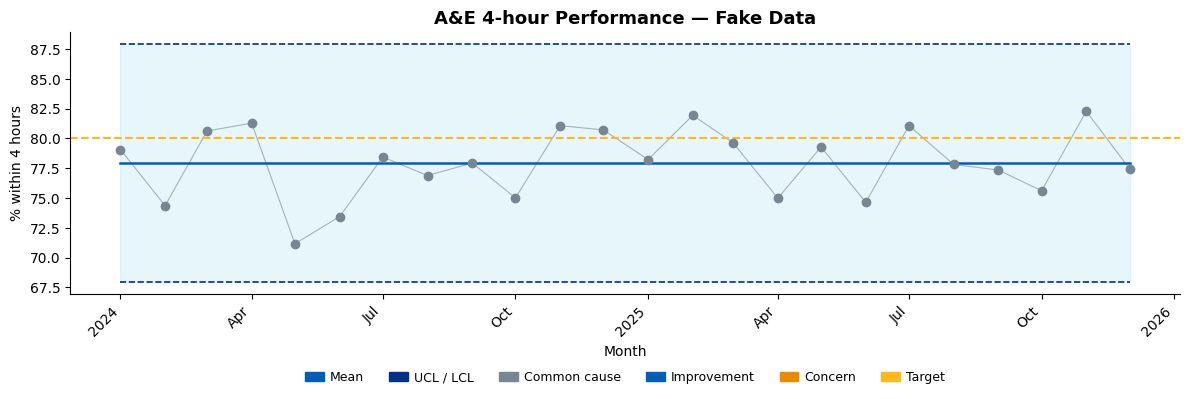

In [2]:
dates = pd.date_range("2024-01-01", periods=24, freq="MS")
xmr_data = pd.DataFrame(
    {"value": np.clip(rng.normal(78, 3.5, 24), 60, 95)},
    index=dates,
)
fig, _ = plot_spc_chart(
    xmr_data,
    chart_type="XmR",
    title="A&E 4-hour Performance — Fake Data",
    xlabel="Month",
    ylabel="% within 4 hours",
    improvement_direction="high",
    target=80,
    show_target=True,
    shade_band=True,
)
save(fig, "chart_xmr.png")
plt.show()

## 3. p chart — proportion (falls per admission, fake)

`p` charts use a numerator and denominator. Limits widen / narrow with subgroup size.

wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_p.png


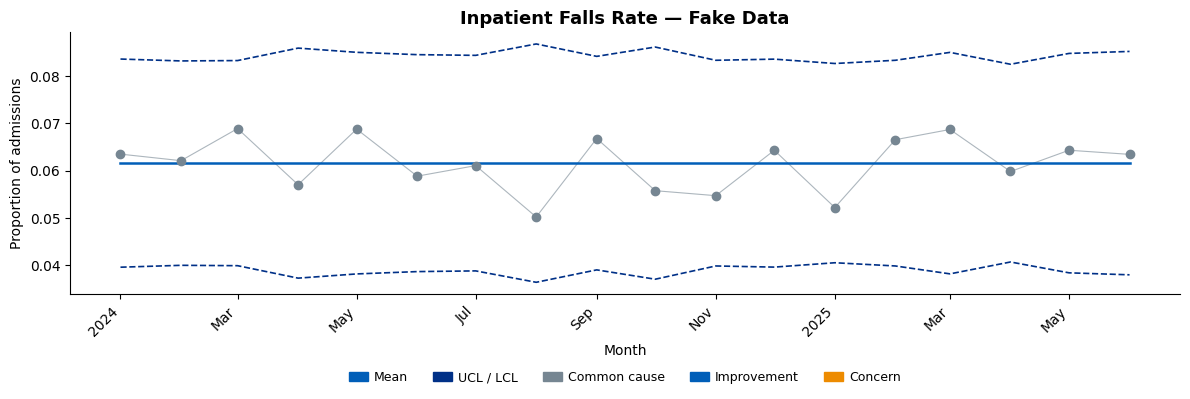

In [3]:
months = pd.date_range("2024-01-01", periods=18, freq="MS")
denominators = rng.integers(800, 1200, 18)
numerators   = rng.binomial(denominators, 0.06)
p_data = pd.DataFrame({"events": numerators, "population": denominators}, index=months)

fig, _ = plot_spc_chart(
    p_data,
    chart_type="p",
    value_col="population",
    numerator_col="events",
    title="Inpatient Falls Rate — Fake Data",
    xlabel="Month",
    ylabel="Proportion of admissions",
    improvement_direction="low",
)
save(fig, "chart_p.png")
plt.show()

## 4. c chart — counts in a fixed exposure (fake)

wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_c.png


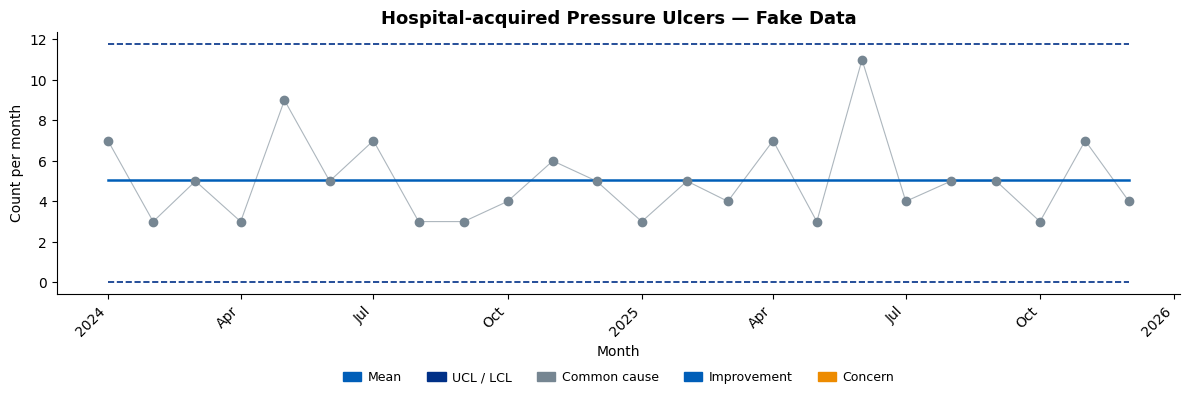

In [4]:
months = pd.date_range("2024-01-01", periods=24, freq="MS")
c_data = pd.DataFrame({"value": rng.poisson(5, 24)}, index=months)
fig, _ = plot_spc_chart(
    c_data,
    chart_type="c",
    title="Hospital-acquired Pressure Ulcers — Fake Data",
    xlabel="Month",
    ylabel="Count per month",
    improvement_direction="low",
)
save(fig, "chart_c.png")
plt.show()

## 4a. u chart — counts per unit with variable exposure (fake)

`u` charts use a count numerator and a variable exposure (population, bed-days,
patient-days, etc.).  Limits widen / narrow with subgroup size.


wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_u.png


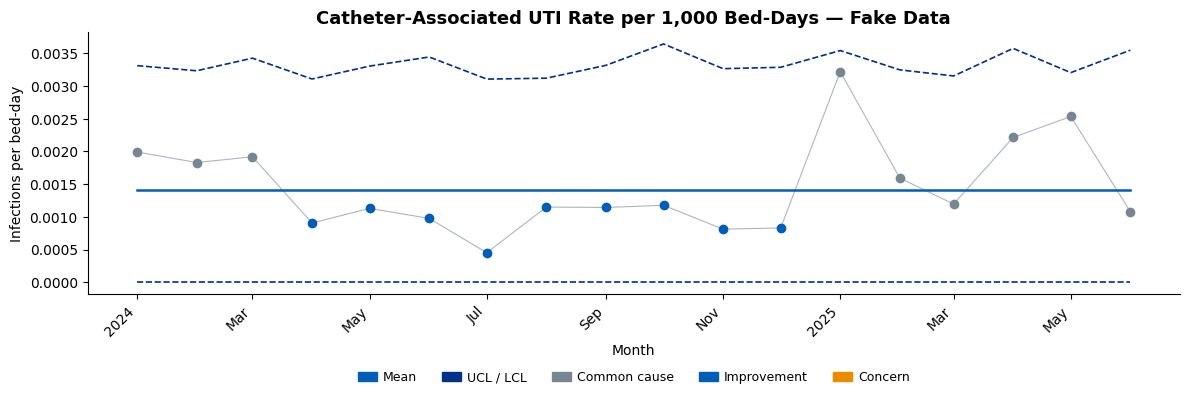

In [5]:
months = pd.date_range("2024-01-01", periods=18, freq="MS")
bed_days = rng.integers(2500, 4500, 18)
infections = rng.poisson(bed_days * 0.0015)
u_data = pd.DataFrame({"value": infections, "subgroup_size": bed_days}, index=months)

fig, _ = plot_spc_chart(
    u_data,
    chart_type="u",
    title="Catheter-Associated UTI Rate per 1,000 Bed-Days — Fake Data",
    xlabel="Month",
    ylabel="Infections per bed-day",
    improvement_direction="low",
)
save(fig, "chart_u.png")
plt.show()


## 4b. t chart — time between rare events (fake)

`t` charts use Nelson's transformation (``Y' = Y ** (1 / 3.6)``) to symmetrise
the skewed distribution of times between rare events such as never-events or
serious incidents.


wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_t.png


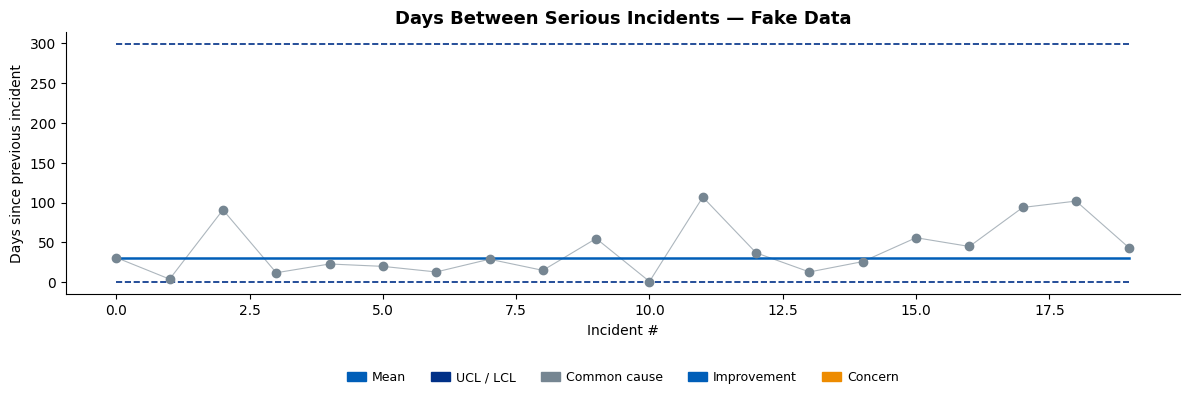

In [6]:
# Days between consecutive serious incidents — longer is better
gap_days = np.concatenate([
    rng.exponential(20, 12),   # baseline
    rng.exponential(45, 8),    # after safety initiative
])
t_data = pd.DataFrame({"value": np.round(gap_days).astype(int)})

fig, _ = plot_spc_chart(
    t_data,
    chart_type="t",
    title="Days Between Serious Incidents — Fake Data",
    xlabel="Incident #",
    ylabel="Days since previous incident",
    improvement_direction="high",
)
save(fig, "chart_t.png")
plt.show()


## 4c. g chart — opportunities between rare events (fake)

`g` charts model the count of opportunities (e.g. patients, procedures)
between consecutive rare events using the geometric distribution.  Useful
when the exposure is a count rather than a time interval.


wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_g.png


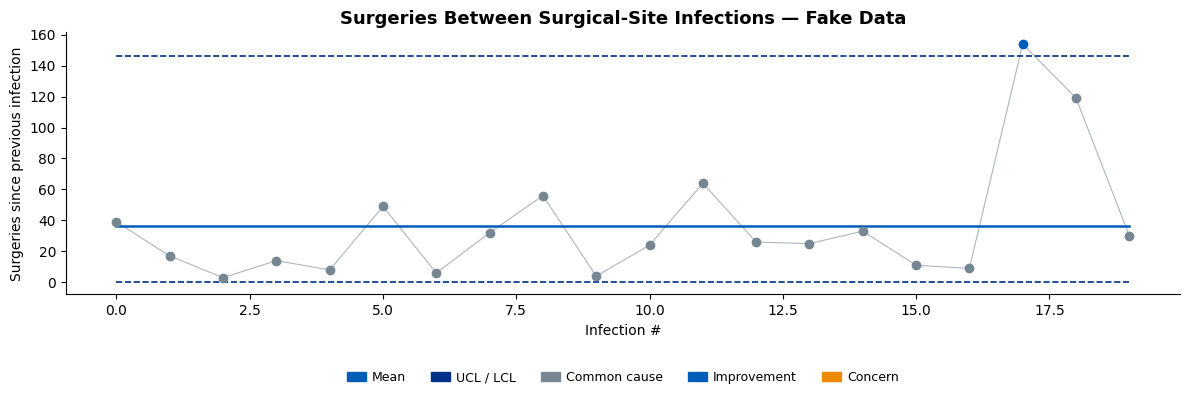

In [7]:
# Number of surgeries between consecutive surgical-site infections
opps = np.concatenate([
    rng.geometric(0.04, 12),   # baseline (~25 surgeries between events)
    rng.geometric(0.02, 8),    # after bundle introduction (~50)
])
g_data = pd.DataFrame({"value": opps})

fig, _ = plot_spc_chart(
    g_data,
    chart_type="g",
    title="Surgeries Between Surgical-Site Infections — Fake Data",
    xlabel="Infection #",
    ylabel="Surgeries since previous infection",
    improvement_direction="high",
)
save(fig, "chart_g.png")
plt.show()


## 5. Run chart — median centre line (fake)

A run chart is a lightweight alternative when you don't yet have enough data
for control limits, or when stability cannot be assumed.

wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_run.png


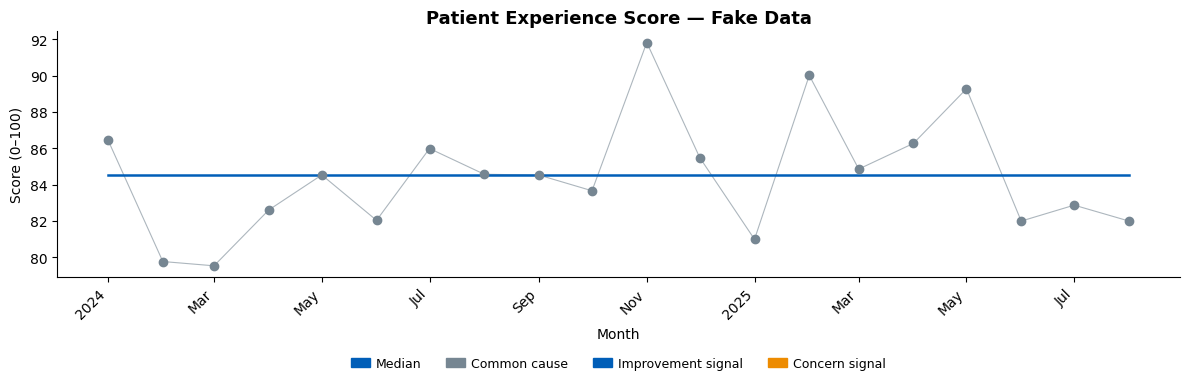

wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_run_dates.png


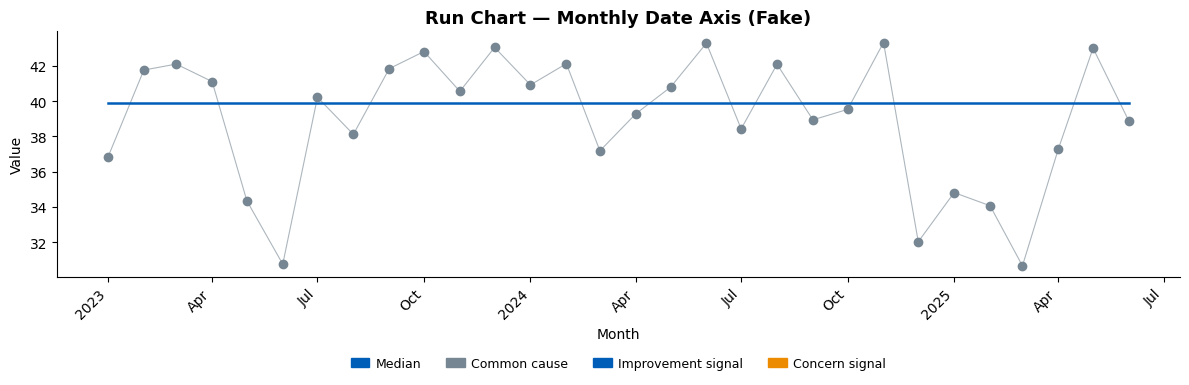

In [8]:
months = pd.date_range("2024-01-01", periods=20, freq="MS")
run_values = np.concatenate([rng.normal(82, 3, 10), rng.normal(86, 2.5, 10)])
run_data = pd.DataFrame({"value": run_values}, index=months)

fig, _ = plot_run_chart(
    run_data,
    title="Patient Experience Score — Fake Data",
    xlabel="Month",
    ylabel="Score (0–100)",
    improvement_direction="high",
)
save(fig, "chart_run.png")
plt.show()

months_long = pd.date_range("2023-01-01", periods=30, freq="MS")
fig, _ = plot_run_chart(
    pd.DataFrame({"value": rng.normal(40, 4, 30)}, index=months_long),
    title="Run Chart — Monthly Date Axis (Fake)",
    xlabel="Month",
    ylabel="Value",
    improvement_direction="high",
)
save(fig, "chart_run_dates.png")
plt.show()

## 6. Change-point annotations (fake)

Mark known interventions on the chart so the reader can connect signals to
real-world changes.

wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_change_points.png


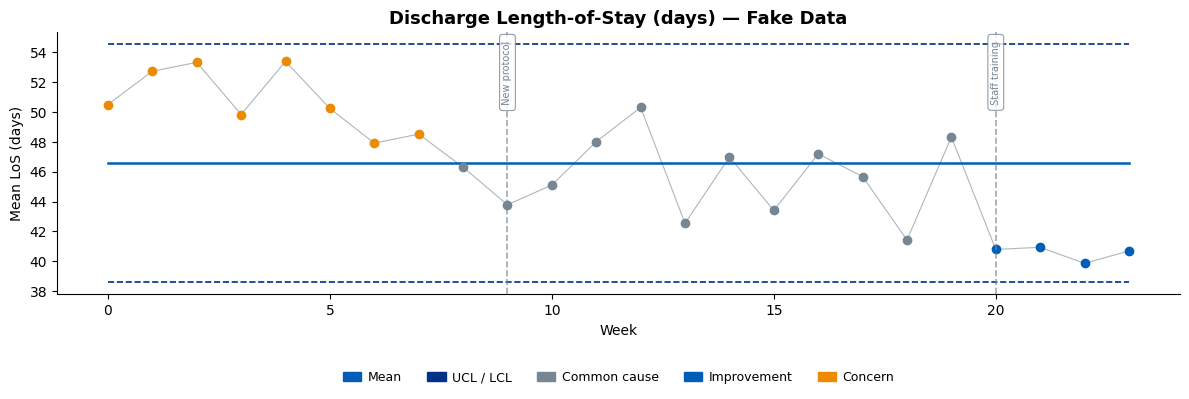

In [9]:
cp_values = np.concatenate([
    rng.normal(50, 2.5, 9),     # baseline
    rng.normal(46, 2.5, 11),    # after new protocol
    rng.normal(42, 2.0, 4),     # after staff training
])
cp_data = pd.DataFrame({"value": cp_values})

fig, _ = plot_spc_chart(
    cp_data,
    chart_type="XmR",
    title="Discharge Length-of-Stay (days) — Fake Data",
    xlabel="Week",
    ylabel="Mean LoS (days)",
    improvement_direction="low",
    change_points=[
        {"x": 9,  "label": "New protocol"},
        {"x": 20, "label": "Staff training"},
    ],
)
save(fig, "chart_change_points.png")
plt.show()

## 7. Date-axis formatting (fake)

`abspc` auto-detects a `DatetimeIndex` or an explicit `x_col` and applies
matplotlib's `ConciseDateFormatter`.

wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_date_axis.png


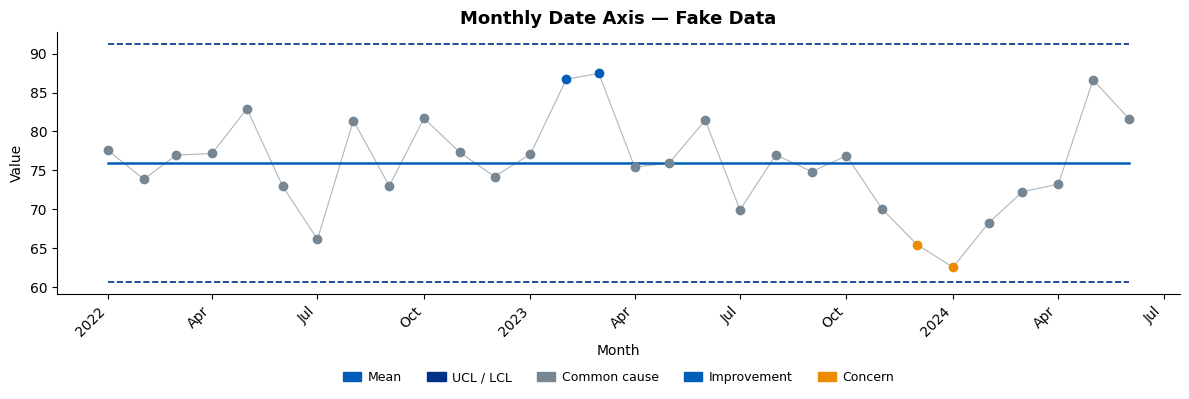

In [10]:
dates = pd.date_range("2022-01-01", periods=30, freq="MS")
date_data = pd.DataFrame({"value": rng.normal(75, 6, 30)}, index=dates)

fig, _ = plot_spc_chart(
    date_data,
    chart_type="XmR",
    title="Monthly Date Axis — Fake Data",
    xlabel="Month",
    ylabel="Value",
)
save(fig, "chart_date_axis.png")
plt.show()

## 8. Auto-rebase on sustained improvement (fake)

When ≥ 8 consecutive points sit on the *improvement* side of the centre line,
`auto_rebase=True` recalculates the limits for the new phase.

wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_auto_rebase.png


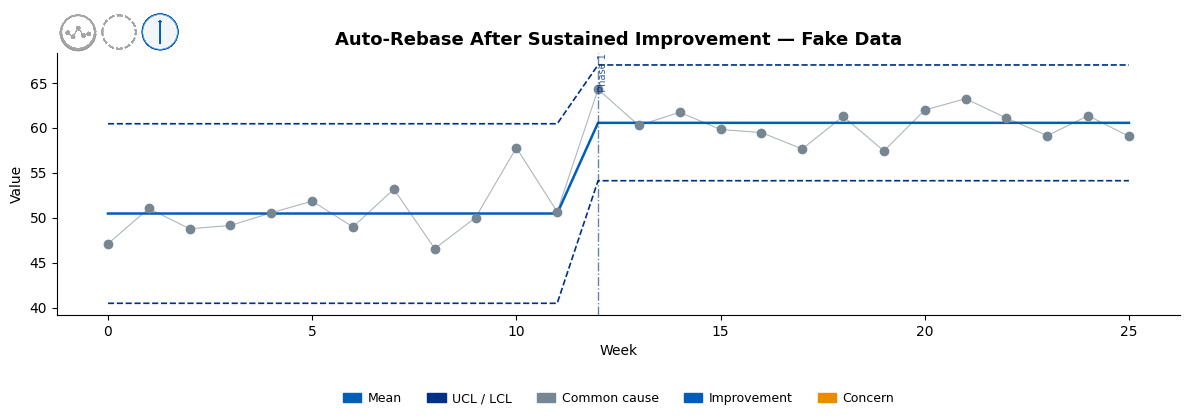

In [11]:
ar_values = np.concatenate([
    rng.normal(50, 3, 12),   # baseline
    rng.normal(60, 3, 14),   # sustained improvement
])
ar_data = pd.DataFrame({"value": ar_values})

fig, _ = plot_spc_chart(
    ar_data,
    chart_type="XmR",
    title="Auto-Rebase After Sustained Improvement — Fake Data",
    xlabel="Week",
    ylabel="Value",
    improvement_direction="high",
    auto_rebase=True,
    show_icons=True,
)
save(fig, "chart_auto_rebase.png")
plt.show()

## 9. Logo placement, target line, MDC icons (fake)

The MDC variation & assurance icons appear at the top-left, an organisation
logo at the top-right. We re-use a packaged icon as a placeholder logo here.

wrote /tmp/workspace/Aneurin-Bevan-University-Health-Board/biu_Making_Data_Count_CustomVisuals/docs/images/chart_with_logo.png


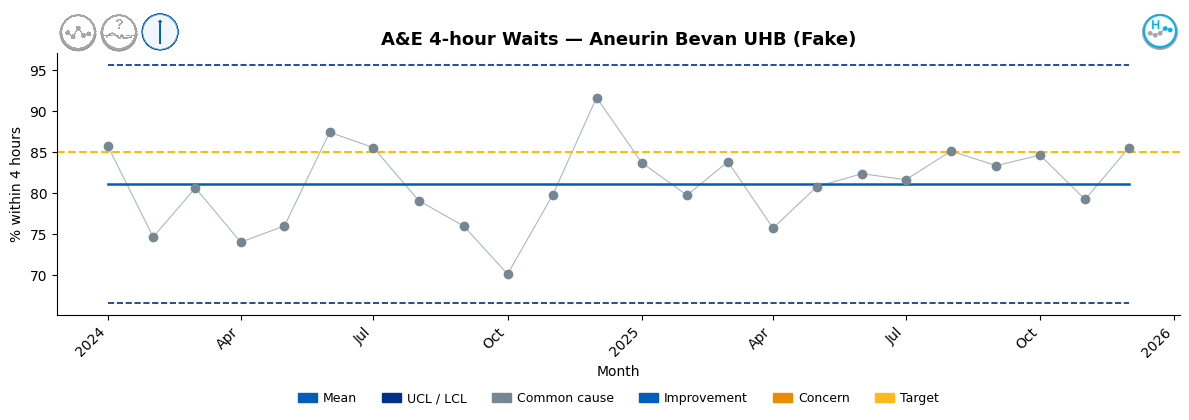

In [12]:
logo = ROOT / "abspc" / "icons" / "variation_improvement_high.png"
months = pd.date_range("2024-01-01", periods=24, freq="MS")
logo_data = pd.DataFrame({"value": np.clip(rng.normal(82, 4, 24), 60, 100)}, index=months)

fig, _ = plot_spc_chart(
    logo_data,
    chart_type="XmR",
    title="A&E 4-hour Waits — Aneurin Bevan UHB (Fake)",
    xlabel="Month",
    ylabel="% within 4 hours",
    improvement_direction="high",
    target=85,
    show_target=True,
    show_icons=True,
    logo_path=str(logo) if logo.exists() else None,
    logo_zoom=0.08,
)
save(fig, "chart_with_logo.png")
plt.show()

## 10. Done

All gallery PNGs in `docs/images/` have been refreshed with fake data on
`abspc` 1.0.0. Re-run this notebook end-to-end whenever the package or the
NHS MDC styling changes.